In [28]:
import os
import glob

from tensorflow_examples.models.pix2pix import pix2pix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
#import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import clear_output
import matplotlib.pyplot as plt

In [29]:
# Install tensorflow_examples from the official TensorFlow models repository
#!pip install git+https://github.com/tensorflow/examples.git


In [30]:
import sys
import skimage
import sklearn
import keras
print('Python       :', sys.version.split('\n')[0])
print('Numpy        :', np.__version__)
print('Skimage      :', skimage.__version__)
print('Scikit-learn :', sklearn.__version__)
print('Keras        :', keras.__version__)
print('Tensorflow   :', tf.__version__)

Python       : 3.11.13 (main, Jun  5 2025, 08:21:08) [Clang 14.0.6 ]
Numpy        : 2.0.2
Skimage      : 0.26.0
Scikit-learn : 1.6.1
Keras        : 3.12.1
Tensorflow   : 2.21.0


In [31]:
topDir = "/Users/triscillar/Documents/Professional development/Journal Submissions/data MDPI/Wildlife Fences Dataset/Still_Images/Segmentation/semantic level masks"


In [32]:
topDir

'/Users/triscillar/Documents/Professional development/Journal Submissions/data MDPI/Wildlife Fences Dataset/Still_Images/Segmentation/semantic level masks'

In [33]:
pwd

'/Users/triscillar/Documents/Professional development/Journal Submissions/data MDPI/Baseline  notebooks'

# Input the data by loading the images and masks

In [34]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224


def load_image(image_path, mask_path):
    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    # Resize image
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH],
        method=tf.image.ResizeMethod.BILINEAR
    )
    # Resize mask
    mask = tf.image.resize(
        mask,
        [IMG_HEIGHT, IMG_WIDTH],
        method=tf.image.ResizeMethod.NEAREST_NEIGHBOR
    )
    # Normalize image
    image = tf.cast(image, tf.float32) / 255.0
    # Convert mask to class labels
    # 0   -> background
    # 255 -> foreground (class 1)
    mask = tf.cast(mask, tf.int32)
    mask = tf.where(mask == 255, 1, 0)

    return image, mask

### Images paths

In [35]:
train_image_paths = sorted(
    glob.glob(os.path.join(topDir, "images", "train_split", "*"))
)

train_mask_paths = sorted(
    glob.glob(os.path.join(topDir, "masks", "train_split", "*"))
)
val_image_paths = sorted(
    glob.glob(os.path.join(topDir, "images", "val_split", "*"))
)

val_mask_paths = sorted(
    glob.glob(os.path.join(topDir, "masks", "val_split", "*"))
)

test_image_paths = sorted(
    glob.glob(os.path.join(topDir, "images", "test_split", "*"))
)

test_mask_paths = sorted(
    glob.glob(os.path.join(topDir, "masks", "test_split", "*"))
)

In [36]:
len(val_image_paths)

69

In [37]:
print(len(test_mask_paths), len(val_mask_paths), len(train_mask_paths))

68 69 549


In [38]:
print(len(test_image_paths), len(val_image_paths), len(train_image_paths))

68 69 549


### Generate tensorflow dataset

In [39]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_image_paths, train_mask_paths)
)
val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_mask_paths)
)
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_image_paths, test_mask_paths)
)

In [40]:
train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.string, name=None))>

In [41]:
TRAIN_LENGTH = len(train_image_paths)
BATCH_SIZE = 12
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

In [42]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [43]:
print(train_dataset)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(224, 224, 1), dtype=tf.int32, name=None))>


### simple augmentation by randomly-flipping an image

In [44]:
class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    # both use the same seed, so they'll make the same random changes.
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels

### Build the input pipeline, applying the augmentation after batching the inputs:

In [45]:
train_batches = (
    train_dataset
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))
val_batches = val_dataset.batch(BATCH_SIZE)
test_batches = test_dataset.batch(BATCH_SIZE)

### Visualize a random image example and its corresponding mask from the dataset

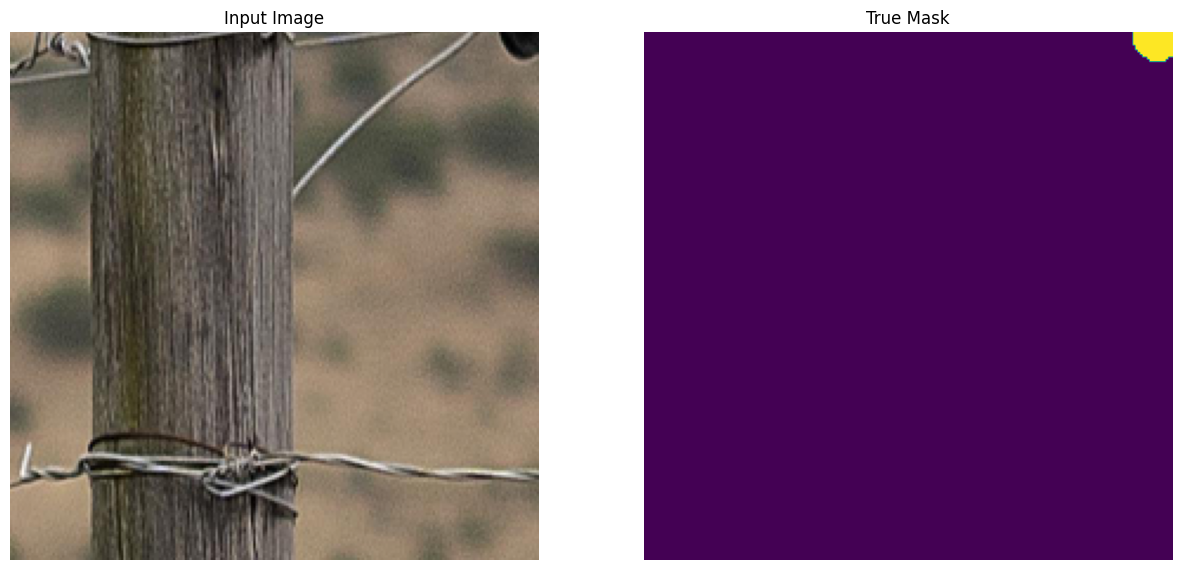

In [46]:
def display(display_list):
 plt.figure(figsize=(15, 15))
 title = ["Input Image", "True Mask", "Predicted Mask"]
 for i in range(len(display_list)):
   plt.subplot(1, len(display_list), i+1)
   plt.title(title[i])
   plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
   plt.axis("off")
 plt.show()
sample_batch = next(iter(train_batches))
random_index = np.random.choice(sample_batch[0].shape[0])
sample_image, sample_mask = sample_batch[0][random_index], sample_batch[1][random_index]
display([sample_image, sample_mask])

# Define the model

In [47]:
base_model = tf.keras.applications.MobileNetV2(input_shape=[224, 224, 3], include_top=False)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)

down_stack.trainable = False

In [48]:
up_stack = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

In [49]:
def unet_model(output_channels:int):
  inputs = tf.keras.layers.Input(shape=[224, 224, 3])

  # Downsampling through the model
  skips = down_stack(inputs)
  x = skips[-1]
  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    concat = tf.keras.layers.Concatenate()
    x = concat([x, skip])

  # This is the last layer of the model
  last = tf.keras.layers.Conv2DTranspose(
      filters=output_channels, kernel_size=3, strides=2,
      padding='same')  #64x64 -> 224x224

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

# Train the model

In [50]:
OUTPUT_CLASSES = 3

model = unet_model(output_channels=OUTPUT_CLASSES)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [51]:
for images, masks in train_batches.take(1):

    print("Image shape:", images.shape)
    print("Mask shape:", masks.shape)
    print("Mask dtype:", masks.dtype)

    unique_values = tf.unique(
        tf.reshape(masks, [-1])
    )[0]

    print("Mask values:", unique_values.numpy())

print("Model output:", model.output_shape)

Image shape: (12, 224, 224, 3)
Mask shape: (12, 224, 224, 1)
Mask dtype: <dtype: 'float32'>
Mask values: [0. 1.]
Model output: (None, 224, 224, 3)


In [52]:
#tf.keras.utils.plot_model(model, show_shapes=True, expand_nested=True, dpi=64)

In [53]:
def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

In [54]:
def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step


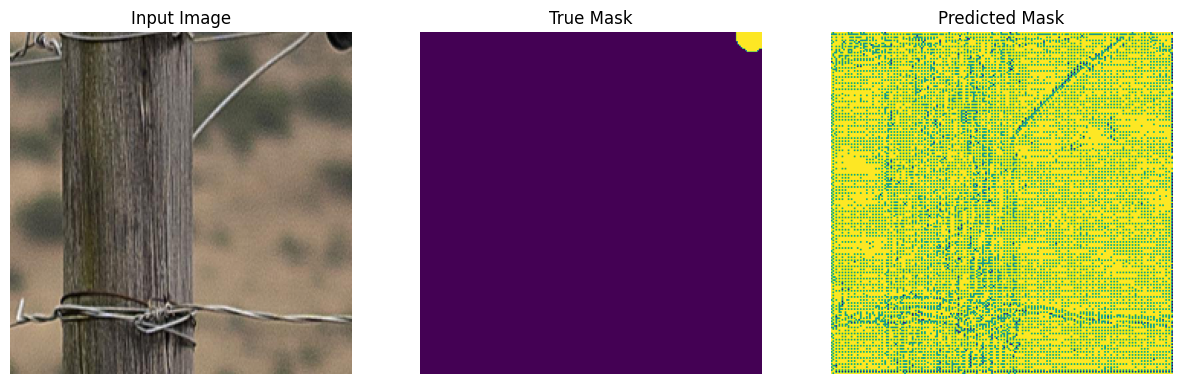

In [55]:
show_predictions()

In [56]:
class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


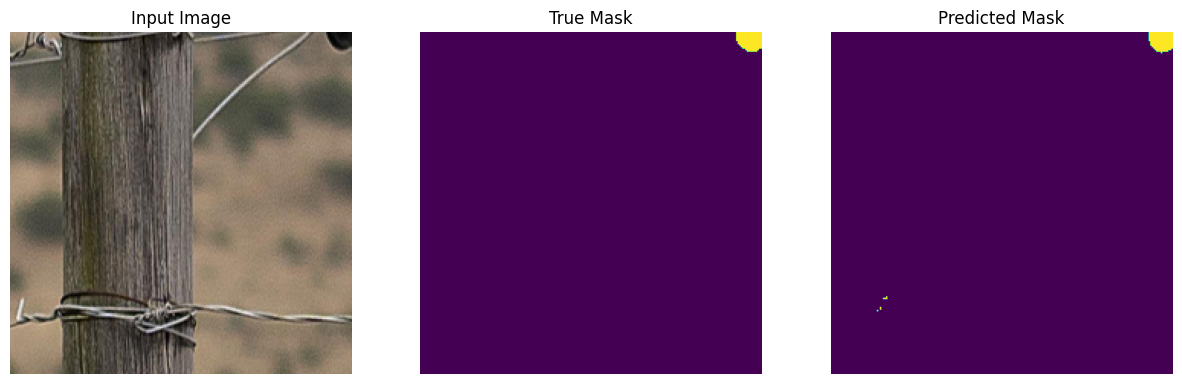


Sample Prediction after epoch 20

45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 447ms/step - accuracy: 0.9929 - loss: 0.0209 - val_accuracy: 0.9850 - val_loss: 0.0387


In [57]:
EPOCHS = 20
VAL_SUBSPLITS = 5
TRAIN_LENGTH = len(train_image_paths)
VAL_LENGTH = len(val_image_paths)

STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

VALIDATION_STEPS = VAL_LENGTH//BATCH_SIZE//VAL_SUBSPLITS

model_history = model.fit(train_batches, epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=val_batches,
                          callbacks=[DisplayCallback()])

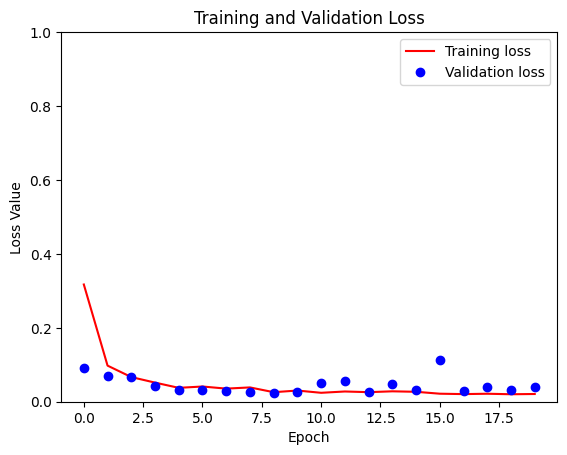

In [58]:
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

plt.figure()
plt.plot(model_history.epoch, loss, 'r', label='Training loss')
plt.plot(model_history.epoch, val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.ylim([0, 1])
plt.legend()
plt.show()

# Make predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step


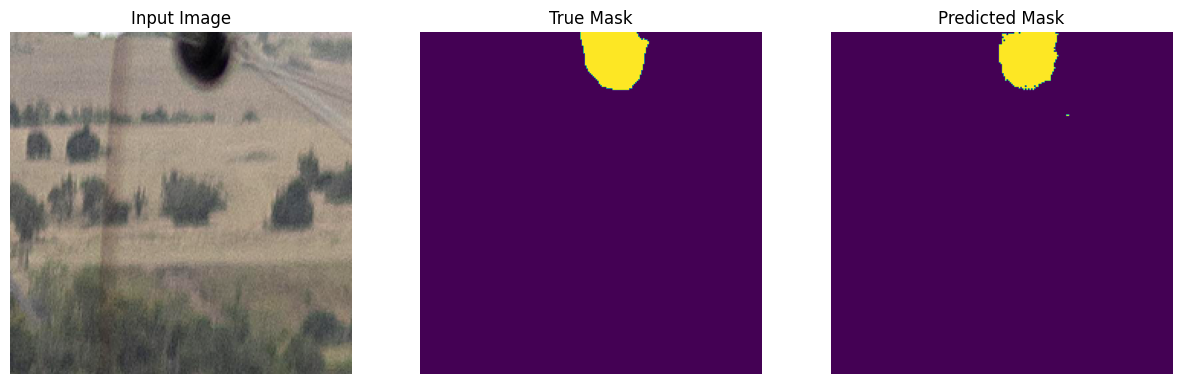

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


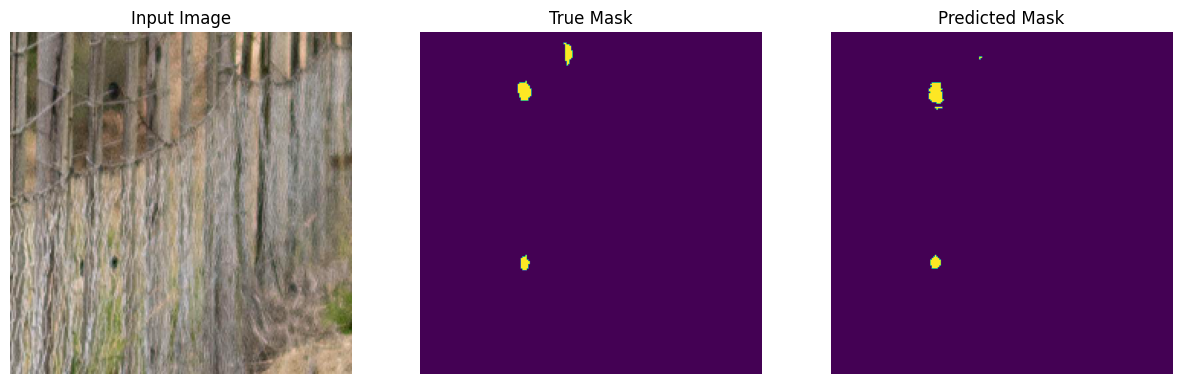

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


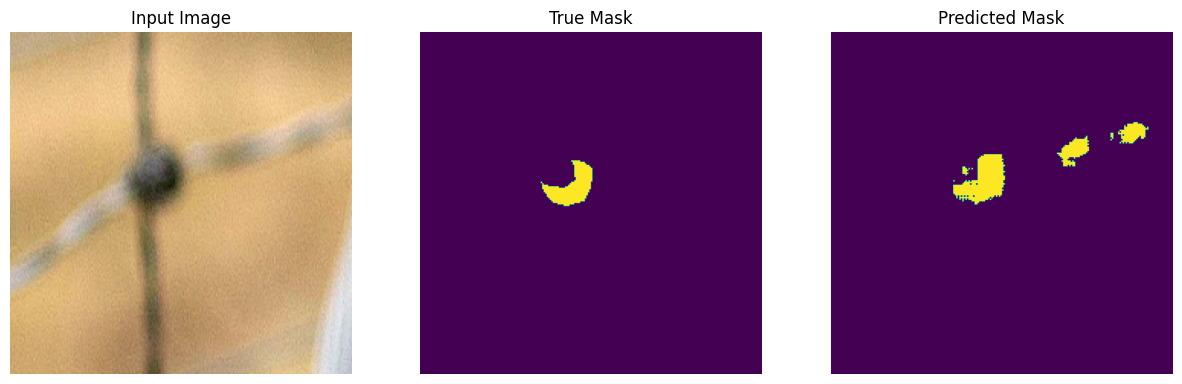

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


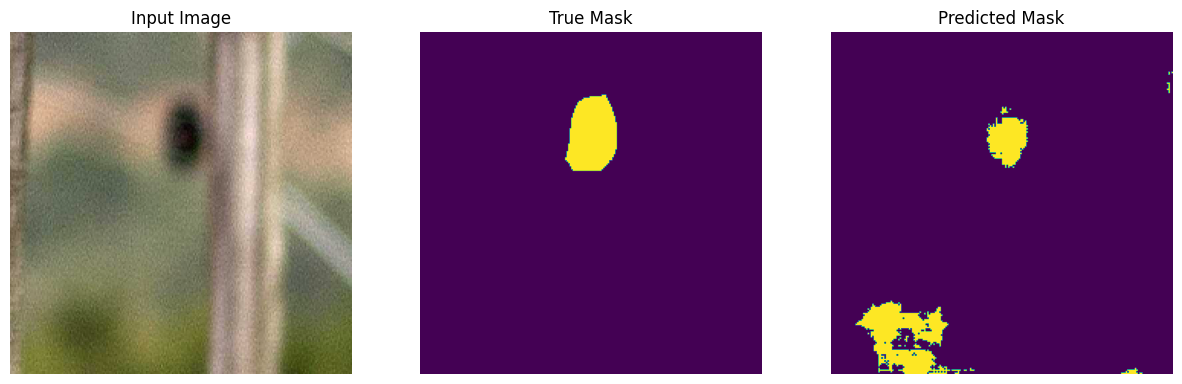

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


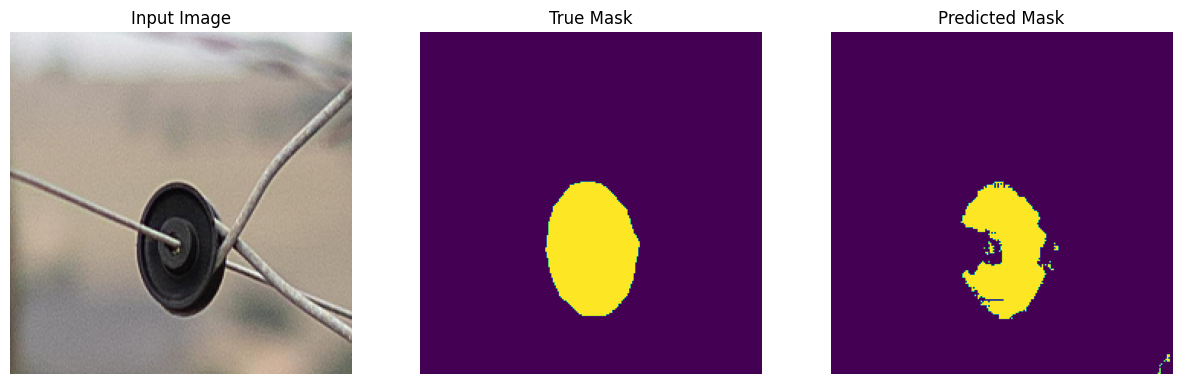

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


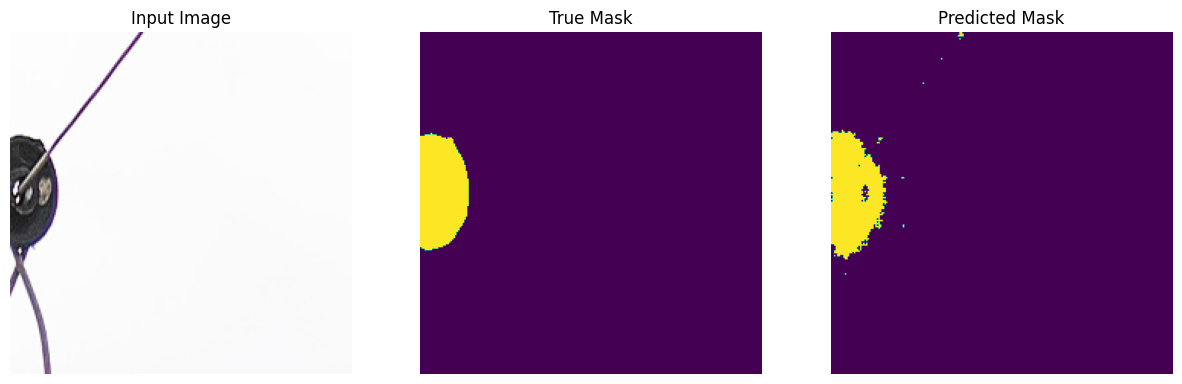

In [59]:
show_predictions(test_batches, 6)